In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Dane do Zadania 1: Sparklines (3 produkty przez 12 miesięcy)
months = np.arange(1, 13)
spark_data = {
    'Zysk Alpha': np.cumsum(np.random.normal(1, 2, 12)) + 20,
    'Zysk Beta': np.cumsum(np.random.normal(-0.5, 1.5, 12)) + 15,
    'Zysk Gamma': np.cumsum(np.random.normal(2, 3, 12)) + 10
}

# Dane do Zadania 2: Annotated Time Series
years = np.arange(2000, 2025)
stock_price = 100 + np.cumsum(np.random.normal(0, 8, len(years)))

# Dane do Zadań dodatkowych
categories_dp =['Wydział IT', 'Wydział HR', 'Wydział Sprzedaży', 'Wydział Marketingu', 'Zarząd']
values_dp = [85, 70, 60, 40, 20]

## 1. Make-over: Sparklines (Iskierki)
*(Inspiracja: Edward Tufte, "The Visual Display of Quantitative Information", str. 171)*

Tufte ukuł termin **Sparklines** (Iskierki), określając je mianem "intensywnych informacyjnie, małych grafik wielkości słowa". Ich celem jest pokazanie trendu i zmienności danych w sposób tak skondensowany, że można je wpleść bezpośrednio w tekst lub tabele. Zgodnie z filozofią maksymalizacji *Data-Ink Ratio*, iskierki są całkowicie pozbawione osi, ramek, siatek czy zbędnych liczb.

W tym zadaniu zbudujemy siatkę 3 małych wykresów pokazujących trendy dla 3 różnych produktów, stosując zasady minimalizmu.

**Instrukcja krok po kroku:**
1. Stwórz układ składający się z 3 wierszy i 1 kolumny używając funkcji `fig, axes = plt.subplots(3, 1, figsize=(6, 3))`. Aby wykresy nie nachodziły na siebie, ustaw odstępy między wierszami za pomocą `plt.subplots_adjust(hspace=0.8)`.
2. Wykorzystaj pętlę `for ax, (name, values) in zip(axes, spark_data.items()):`, aby przeiterować przez przygotowane osie oraz dane produktów.
3. Wewnątrz pętli: narysuj linię trendu na bieżącej osi (`ax`) za pomocą funkcji `plot()`. Użyj koloru czarnego i grubości linii `linewidth=1`.
4. Usuń całkowicie układ współrzędnych (linie osi, liczby, ramki) z każdego małego wykresu poleceniem `ax.axis('off')`.
5. Dodaj na początku każdej linii nazwę produktu: użyj funkcji `ax.text()` ze współrzędnymi X wyznaczonymi przez pierwszy miesiąc (`months[0]`) oraz Y przez pierwszą wartość (`values[0]`). Ustaw parametr `ha='right'` (wyrównanie do prawej), aby tekst znalazł się przed linią, oraz `va='center'`.
6. Na końcu każdej linii dodaj małą czerwoną kropkę oznaczającą ostatnią zanotowaną wartość. Użyj funkcji `ax.scatter()` dla ostatniego elementu list `months` i `values`. Ustaw kolor na `'red'`, rozmiar `s=15` oraz `zorder=3`.
7. Na prawo od czerwonej kropki dopisz dokładną wartość liczbową: ponownie użyj funkcji `ax.text()`, ustawiając kolor na czerwony i formatując liczbę do jednego miejsca po przecinku (np. `f' {values[-1]:.1f}'`).

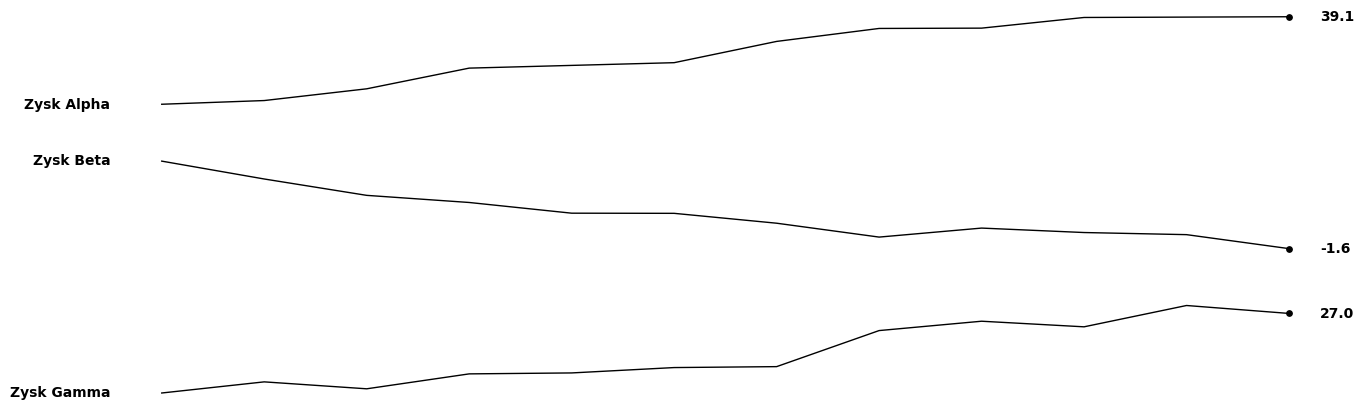

In [ ]:
#@title Miejsce na Twój kod

# Krok 1: Stworzenie układu
fig, axes = plt.subplots(3, 1, figsize=(16, 5))
plt.subplots_adjust(hspace=0.5)

# Krok 2: Iteracja za pomocą pętli for
for ax, (name, values) in zip(axes, spark_data.items()):
    # Krok 3: Rysowanie linii
    ax.plot(months, values, color='black', linewidth=1)

    # Krok 4: Wyłączenie osi
    ax.axis('off')

    # Krok 5: Etykieta z nazwą po lewej
    ax.text(months[0] - 0.5, values[0], name, ha='right', va='center', fontsize=10, fontweight='bold')

    # Krok 6: Kropka końcowa
    ax.scatter(months[-1], values[-1], color='black', s=15, zorder=3)

    # Krok 7: Etykieta numeryczna po prawej
    ax.text(months[-1] + 0.3, values[-1], f'{values[-1]:.1f}', color='black', va='center', fontsize=10, fontweight='bold')

plt.show()

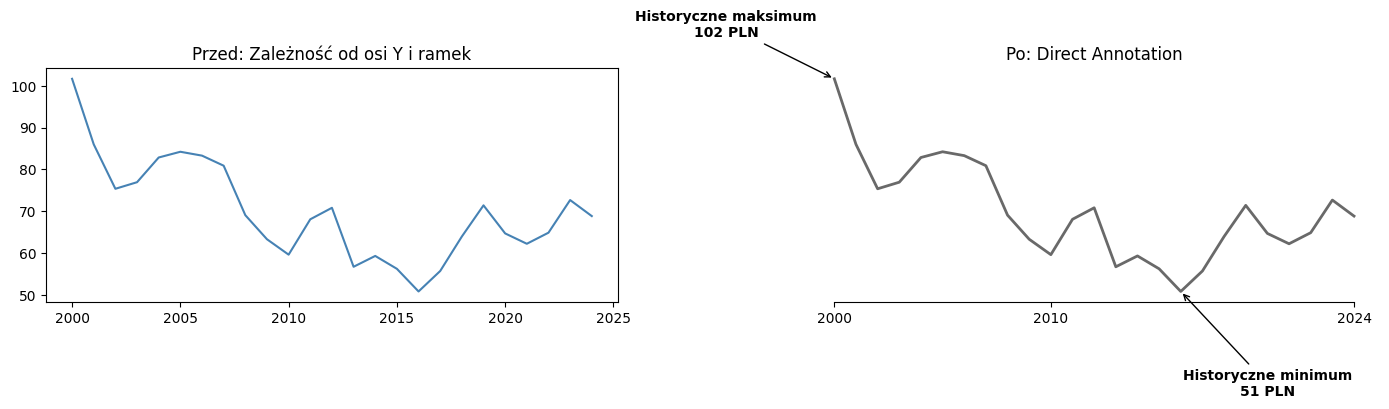

In [ ]:
#@title Miejsce na Twój kod

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Krok 1: LEWY WYKRES (Standardowy)
ax1.plot(years, stock_price, color='steelblue')
ax1.set_title("Przed: Zależność od osi Y i ramek")

# Krok 2: PRAWY WYKRES (Wyczyszczona linia)
ax2.plot(years, stock_price, color='dimgray', linewidth=2)

# Krok 3: Znalezienie punktów ekstremalnych
max_idx = np.argmax(stock_price)
max_val, max_year = stock_price[max_idx], years[max_idx]

min_idx = np.argmin(stock_price)
min_val, min_year = stock_price[min_idx], years[min_idx]

# Krok 4: Usuwanie ramek
for spine in ['top', 'right', 'left']:
    ax2.spines[spine].set_visible(False)

# Krok 5: Usuwanie skali osi Y
ax2.tick_params(left=False, labelleft=False)

# Krok 6: Adnotacja dla MAKSIMUM
ax2.annotate(
    f'Historyczne maksimum\n{max_val:.0f} PLN',
    xy=(max_year, max_val),
    xytext=(max_year - 5, max_val + 10),
    arrowprops=dict(color='black', arrowstyle='->', lw=1),
    fontsize=10, fontweight='bold', ha='center'
)

# Krok 7: Adnotacja dla MINIMUM
ax2.annotate(
    f'Historyczne minimum\n{min_val:.0f} PLN',
    xy=(min_year, min_val),
    xytext=(min_year + 4, min_val - 25),
    arrowprops=dict(color='black', arrowstyle='->', lw=1),
    fontsize=10, fontweight='bold', ha='center'
)

# Krok 8: Range-frame dla osi X
ax2.spines['bottom'].set_bounds(years.min(), years.max())
ax2.set_xticks([years.min(), 2010, years.max()])

ax2.set_title("Po: Direct Annotation")
plt.tight_layout()
plt.show()

## 2. Make-over: Data-ink we wskaźnikach i adnotacjach
*(Inspiracja: Edward Tufte, "The Visual Display of Quantitative Information", str. 177–180)*

Edward Tufte promuje zasadę integrowania tekstu, liczb i obrazu (tzw. *Direct Annotation*). Według niego, zamiast zmuszać czytelnika do szukania wartości na bocznej osi, lepiej opisać kluczowe punkty danych bezpośrednio na wykresie.

W tym przykładzie usuniemy całą oś Y. Jej rolę przejmą dwie adnotacje: dla **maksimum** i **minimum** historycznego. Dzięki temu "atrament" zużyty na ramki i siatkę siatkę osi Y zostaje zastąpiony czystą informacją.

**Instrukcja krok po kroku:**
1. Na `ax1` narysuj standardową linię: `ax1.plot(years, stock_price)`. Zostaw domyślne ramki i osie.
2. Na `ax2` narysuj tę samą linię, ustaw kolor `'dimgray'`, grubość `linewidth=2` i wyłącz znaczniki danych.
3. Znajdź wartości skrajne:
   - Maksimum: `max_idx = np.argmax(stock_price)`, wyciągnij `max_val` oraz `max_year = years[max_idx]`.
   - Minimum: `min_idx = np.argmin(stock_price)`, wyciągnij `min_val` oraz `min_year = years[min_idx]`.
4. Usuń górną, prawą i lewą ramkę osi na `ax2` (`spines['...'].set_visible(False)`). Wyłączamy lewą oś, bo konkretne liczby podamy w adnotacjach.
5. Ukryj wszystkie znaczniki i liczby na osi Y: `ax2.tick_params(left=False, labelleft=False)`.
6. Dodaj adnotację dla **maksimum**: użyj `ax2.annotate()`. Punktem docelowym (`xy`) jest najwyższy punkt, a tekst (`xytext`) umieść nieco obok. Dodaj strzałkę `arrowprops`.
7. Dodaj adnotację dla **minimum**: analogicznie użyj `ax2.annotate()`. Dobierz `xytext` tak, aby napis nie nachodził na linię wykresu (np. przesuń go w dół).
8. Zastosuj zasadę *Range-frame* dla osi X: przytnij dolną ramkę dokładnie do zakresu lat (`set_bounds`).

## Zadania dodatkowe dla chętnych

### A. Cleveland Dot Plot zamiast wykresu słupkowego
*(Inspiracja: Edward Tufte, "The Visual Display of Quantitative Information", str. 126-128)*

Tufte często sugeruje zastąpienie ciężkiego wykresu słupkowego za pomocą tzw. **Cleveland Dot Plot** – czyli poziomej linii (wskaźnika) z kropką na końcu. Taki wykres ma znacznie wyższe *Data-Ink Ratio*, ponieważ usuwa masywne bloki koloru, które nie niosą dodatkowej informacji, a jedynie obciążają wzrok.

**Instrukcja krok po kroku:**
1. Przygotuj dane: `categories_dp = ['Produkt A', 'Produkt B', 'Produkt C', 'Produkt D']` oraz `values_dp = [25, 45, 15, 30]`.
2. Zbuduj dwa wykresy obok siebie: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`.
3. Na `ax1` narysuj klasyczny, "atramentochłonny" wykres słupkowy poziomy funkcją `ax1.barh(categories_dp, values_dp)`. Dodaj tytuł "Przed: Ciężkie słupki".
4. Na `ax2` zamiast słupków użyj funkcji `ax2.hlines()`. Jako argumenty podaj: `y=categories_dp`, `xmin=0` oraz `xmax=values_dp`. Ustaw kolor na `'gray'` i szerokość `linewidth=1`. To są Twoje "prowadnice".
5. Na końcach tych linii dorysuj wyraźne kropki funkcją `ax2.plot(values_dp, categories_dp, 'o')`. Ustaw kolor na `'black'`, a wielkość znacznika na `markersize=8`. Ustaw `zorder=3`, aby kropki były nad liniami.
6. Oczyść `ax2` z zbędnego atramentu: usuń wszystkie ramki (`top`, `right`, `left`, `bottom`) za pomocą metody `set_visible(False)` na `ax2.spines`.
7. Dodaj tytuł do prawego wykresu i wyświetl całość.

### B. Proporcje wykresu (Aspect Ratio) i "Złoty podział"
*(Inspiracja: Edward Tufte, "The Visual Display of Quantitative Information", str. 186–190)*

Zjawisko, które Tufte opisuje jako kluczowe dla czytelności szeregów czasowych, to odpowiednie nachylenie linii (tzw. *banking to 45 degrees*). Jeśli wykres jest zbyt "wysoki", fluktuacje wydają się agresywne i chaotyczne. Jeśli jest odpowiednio horyzontalny (często zbliżony do Złotego Podziału), oko łatwiej wyłapuje makro-trendy.

**Instrukcja krok po kroku:**
1. W pierwszej kolejności stwórz wykres o wymiarach kwadratowych, wywołując `plt.figure(figsize=(5, 5))`. Narysuj na nim dane giełdowe `stock_price`. Zauważ, jak bardzo "poszarpany" i nerwowy wydaje się ten trend.
2. Następnie stwórz drugi wykres w nowej komórce (lub pod spodem), używając układu horyzontalnego: `plt.figure(figsize=(15, 3))`. Narysuj te same dane.
3. Porównaj oba obrazy. Zauważ, jak szeroki i krótki wykres "wygładza" wzrokowo małe wahania, pozwalając skupić się na rzeczywistym kierunku zmian, co Tufte uznaje za fundament uczciwej prezentacji danych.

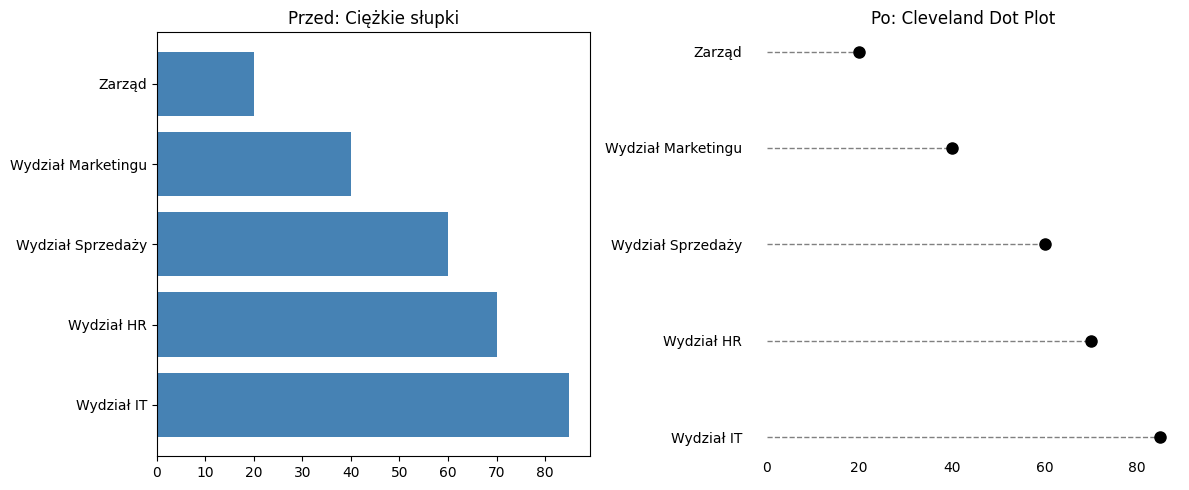

In [ ]:
# Zadanie A

# --- ZADANIE A: Cleveland Dot Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Lewy wykres: Tradycyjne słupki (dużo atramentu)
ax1.barh(categories_dp, values_dp, color='steelblue')
ax1.set_title("Przed: Ciężkie słupki")

# Prawy wykres: Cleveland Dot Plot (wysoki Data-Ink Ratio)
# Krok 4: Poziome linie prowadzące
ax2.hlines(y=categories_dp, xmin=0, xmax=values_dp, color='gray', linewidth=1, linestyle='--')
# Krok 5: Kropki na końcach
ax2.plot(values_dp, categories_dp, 'o', color='black', markersize=8, zorder=3)

# Krok 6: Usuwanie wszystkich ramek
for spine in ['top', 'right', 'left', 'bottom']:
    ax2.spines[spine].set_visible(False)

# Usuwamy ticki dla maksymalnej czystości, zostawiamy tylko napisy kategorii
ax2.tick_params(axis='both', which='both', length=0)

ax2.set_title("Po: Cleveland Dot Plot")
plt.tight_layout()
plt.show()

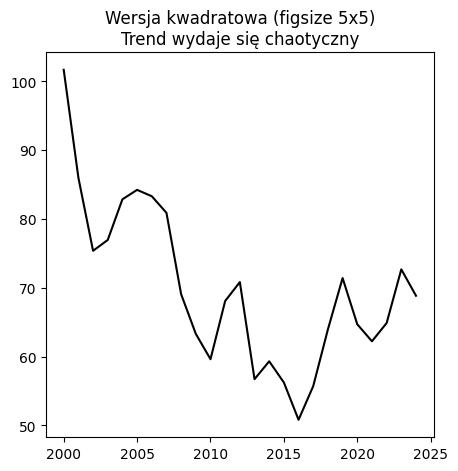

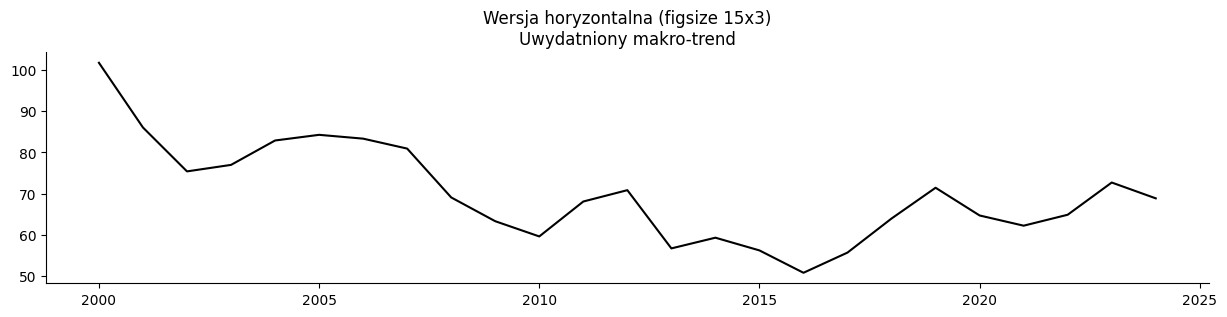

In [ ]:
# --- ZADANIE B: Aspect Ratio ---

# 1. Wykres kwadratowy (poszarpany)
plt.figure(figsize=(5, 5))
plt.plot(years, stock_price, color='black')
plt.title("Wersja kwadratowa (figsize 5x5)\nTrend wydaje się chaotyczny")
plt.show()

# 2. Wykres horyzontalny (wygładzony trend - Tufte style)
plt.figure(figsize=(15, 3))
plt.plot(years, stock_price, color='black')
plt.title("Wersja horyzontalna (figsize 15x3)\nUwydatniony makro-trend")

# Dodatkowy szlif Tufte'owski dla wersji horyzontalnej
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

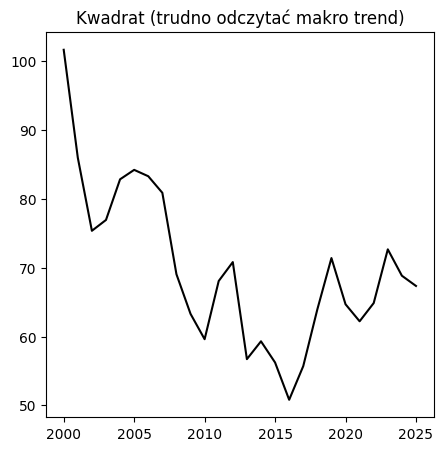

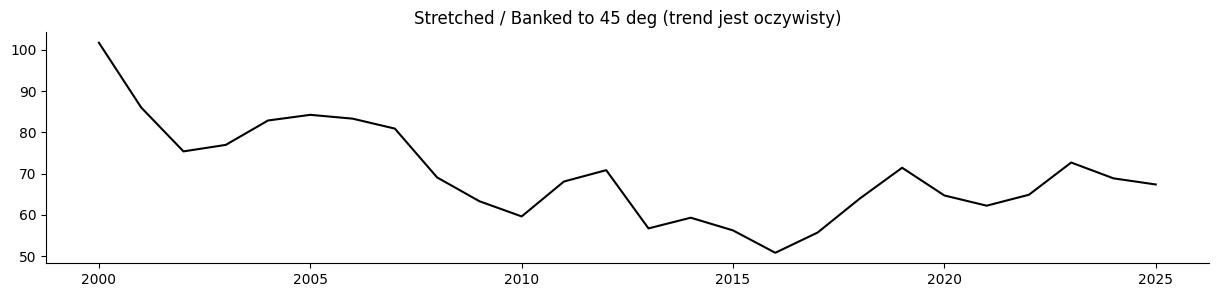

In [ ]:
# Zadanie B
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(years, stock_price, color='black')
ax.set_title("Kwadrat (trudno odczytać makro trend)")
plt.show()

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(years, stock_price, color='black')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.set_title("Stretched / Banked to 45 deg (trend jest oczywisty)")
plt.show()